## Memory repertoire diversity across ages and time

In [1]:

import numpy as np
import pyrepseq as prs
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import Line2D

import repertoire_simulator.lib as lib

plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

/Users/james/Documents/Projects/repertoire_sims_2026/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Richness and diversity in TABLO

In [2]:
tablo = pd.read_csv(DATA_PATH+'tablo/processed/full_table.csv.gz',sep=',')
tablo_memory = tablo[(tablo['annotation_L2'] == 'Memory')]
tablo_memory_blood = tablo[(tablo['annotation_L2'] == 'Memory') & (tablo['origin'] == 'PBMC')]
tablo_memory_tonsil = tablo[(tablo['annotation_L2'] == 'Memory') & (tablo['origin'] == 'Tonsil')]
meta = pd.read_csv(DATA_PATH+'tablo/nonprocessed/10MT_HLA_030123.csv.gz',index_col=0)

In [3]:
dfs = [tablo_memory_blood, tablo_memory_tonsil, tablo_memory]
locs = ["blood", "tonsil", "global"]
metrics = []
for i, df in enumerate(dfs):
    for donor, dfg in df.groupby('donor'):
        
        clone_sizes = np.array(dfg['full_nt'].value_counts())
        
        pc = prs.pc_n(clone_sizes)
        binned_counts = np.bincount(clone_sizes)
        chao1 = prs.chao1(binned_counts[1:])
        
        metrics.append({"donor": donor, "loc":locs[i], "age":meta.loc[donor]['Age'], 'chao1': chao1, 'Seff': 1/pc})
        
df_metrics = pd.DataFrame(metrics)

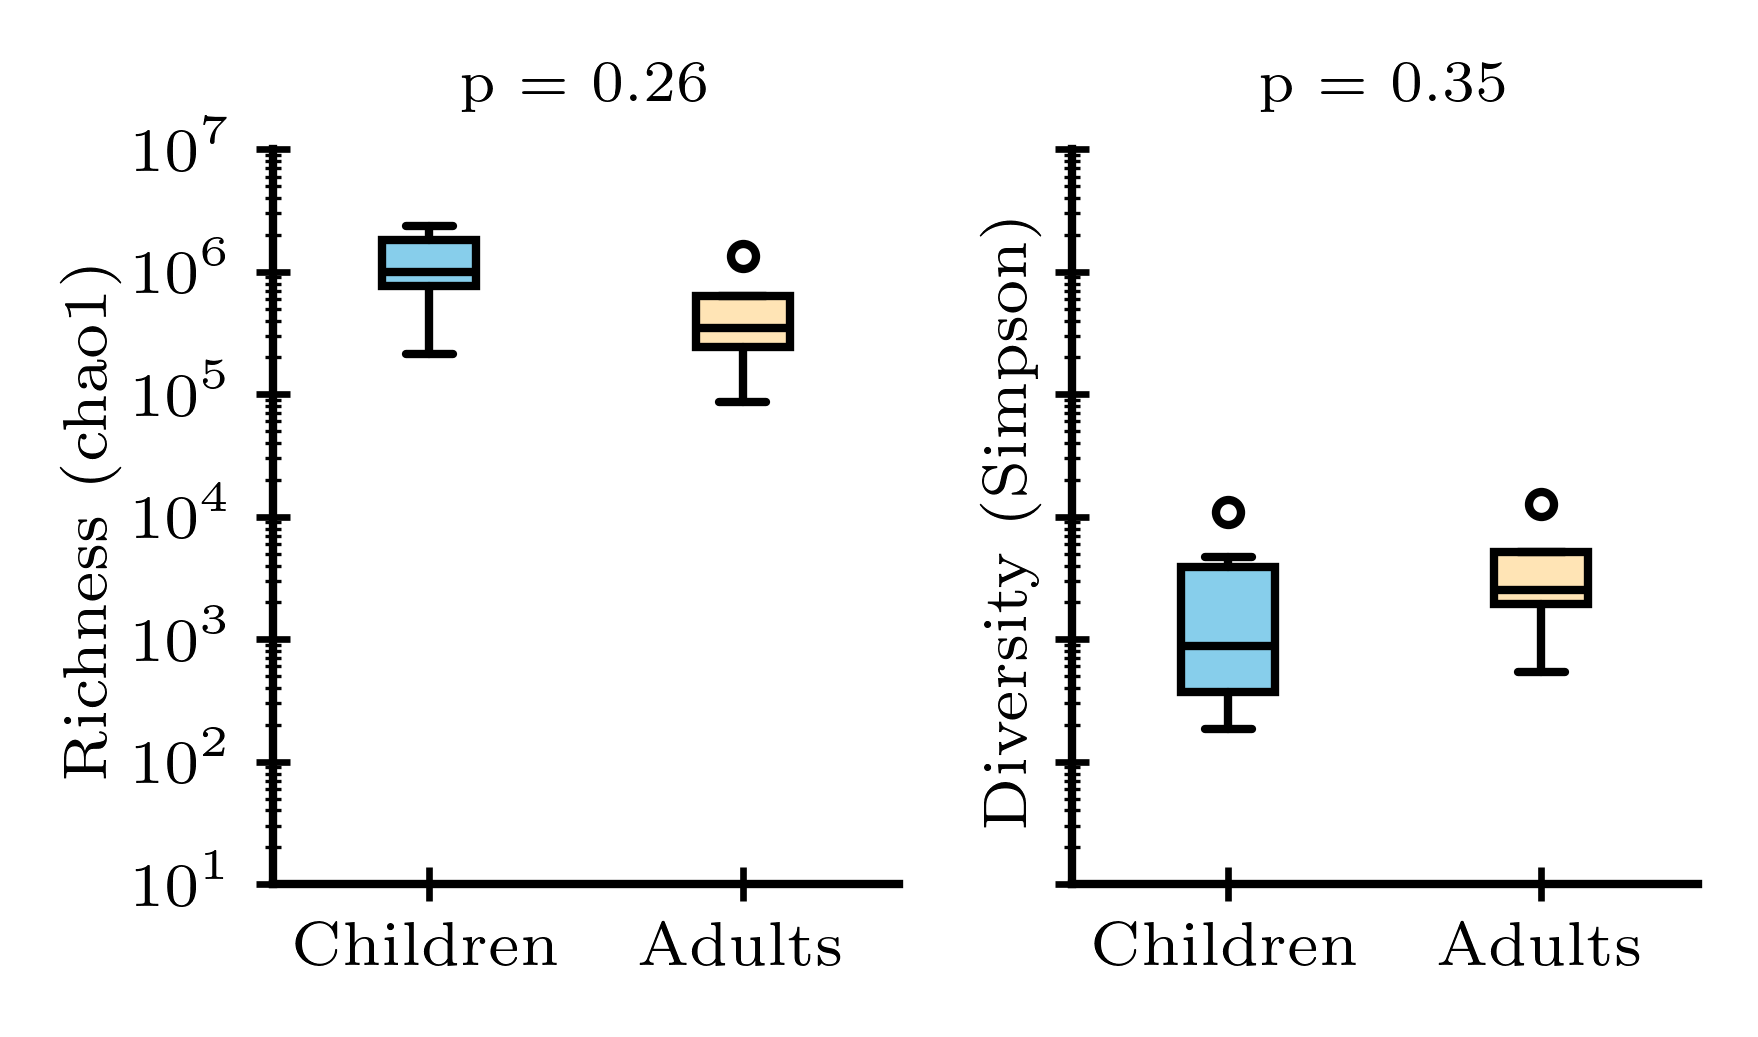

In [4]:
loc = 'blood'
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] <= 10)],
                                                      df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] > 10)])

plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Tonsil 

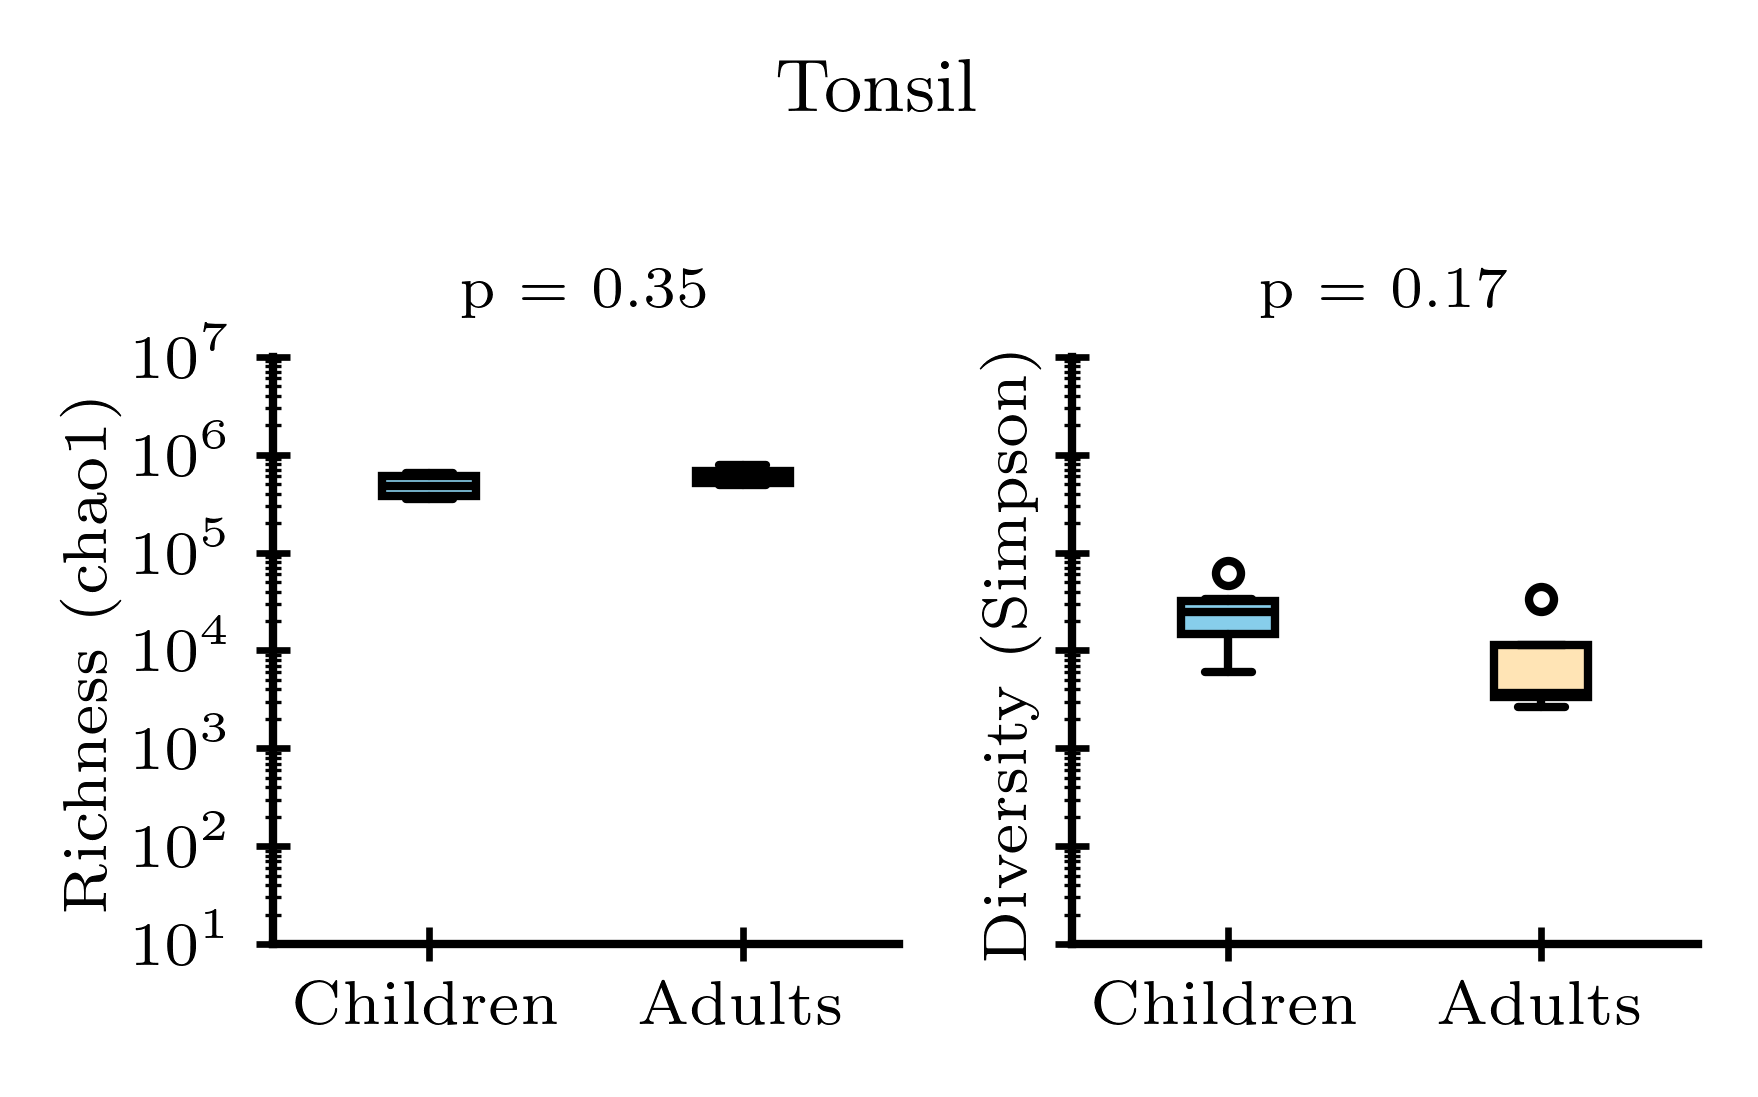

In [14]:
loc = 'tonsil'
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] <= 10)],
                                                      df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] > 10)])
fig.suptitle("Tonsil")
plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity_tonsil.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Global (blood and tonsil)

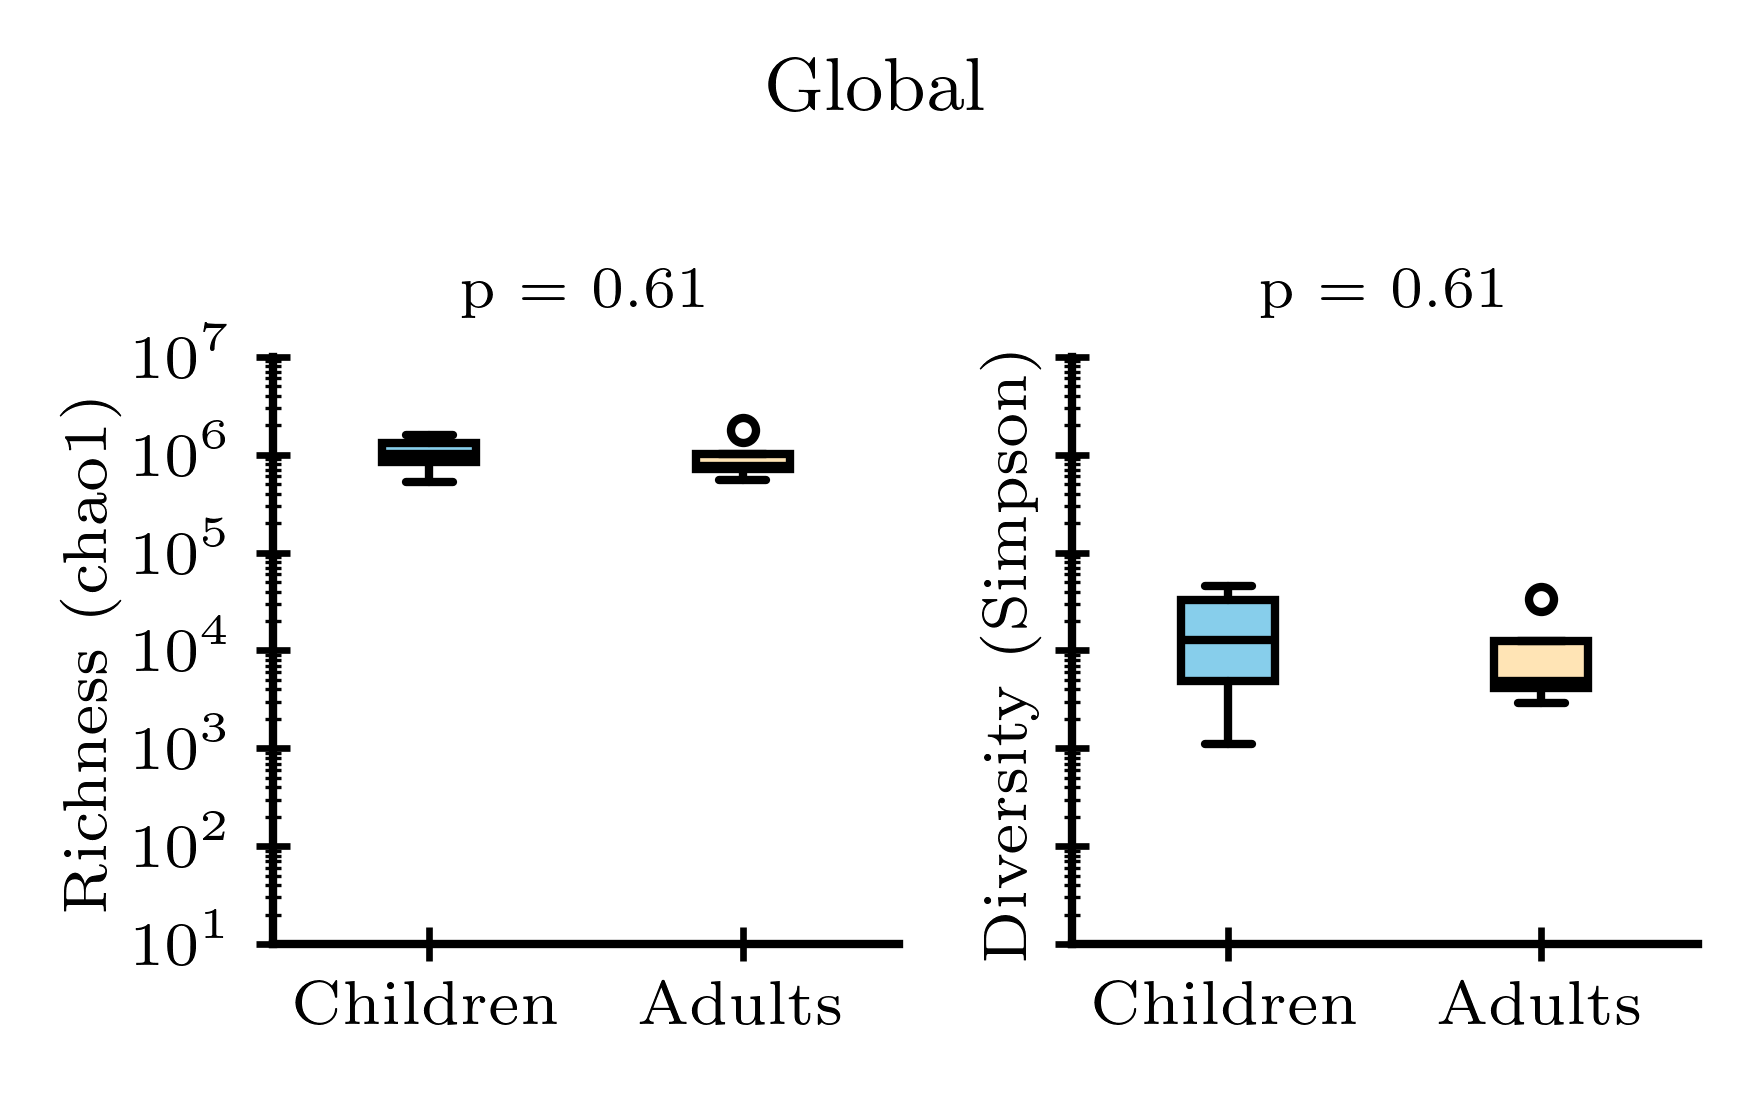

In [9]:
loc = 'global'
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] <= 10)],
                                                      df_metrics[(df_metrics['loc'] == loc) & (df_metrics['age'] > 10)])
fig.suptitle("Global");

## Global and local diversity

In [10]:
tablo_memory = tablo[(tablo['annotation_L2'] == 'Memory')]

dfs = [tablo_memory_blood, tablo_memory_tonsil, tablo_memory]
locs = ["blood", "tonsil", "global"]
metrics_per_loc = []
for i, df in enumerate(dfs):
    for donor, dfg in df.groupby('donor'):
        
        clone_sizes = np.array(dfg['full_nt'].value_counts())
        
        pc = prs.pc_n(clone_sizes)
        binned_counts = np.bincount(clone_sizes)
        chao1 = prs.chao1(binned_counts[1:])
        
        metrics_per_loc.append({"donor": donor, "loc":locs[i], "age":meta.loc[donor]['Age'], 'chao1': chao1, 'Seff': 1/pc})
        
df_metrics_per_loc = pd.DataFrame(metrics_per_loc)
children_metrics_per_loc = df_metrics[df_metrics['age'] <= 10]
adult_metrics_per_loc = df_metrics[df_metrics['age'] > 10]

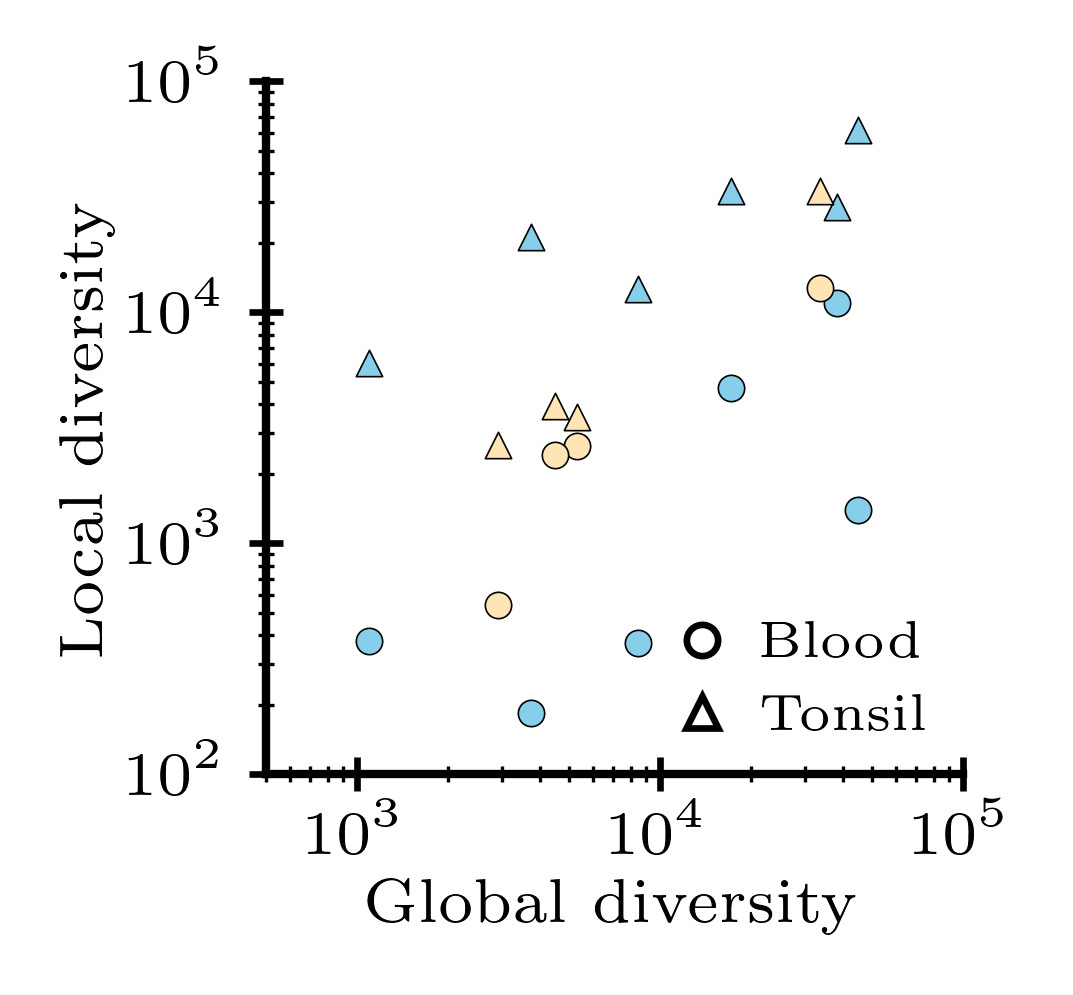

In [11]:
fig, ax = plt.subplots(figsize=(1.5, 1.5))
box_colors = ["skyblue", "moccasin"]
for donor, dfg in df_metrics.groupby('donor'):
    
    adult = dfg['age'].iloc[0] > 10
    color = box_colors[1]
    if not adult:
        color = box_colors[0]
    
    ax.scatter(dfg[dfg['loc'] == 'global']['Seff'], dfg[dfg['loc'] == 'blood']['Seff'], c=color, edgecolors='black', linewidths=0.2, s=10)
    ax.scatter(dfg[dfg['loc'] == 'global']['Seff'], dfg[dfg['loc'] == 'tonsil']['Seff'], c=color, edgecolors='black', linewidths=0.2, marker='^', s=10)
    
ax.set_xlabel("Global diversity")
ax.set_ylabel("Local diversity")
ax.set_xscale('log')
ax.set_yscale('log')

loc_legend = [Line2D([0], [0], marker='o', color='black', markerfacecolor='white', linestyle='none', markersize=5, label='Blood'), 
              Line2D([0], [0], marker='^', color='black', markerfacecolor='white', linestyle='none', markersize=5, label='Tonsil')]

ax.set_xlim(5e2, 1e5)
ax.set_ylim(1e2, 1e5)
ax.legend(handles=loc_legend, frameon=False, loc='lower right');

## Tonsil vs blood metrics

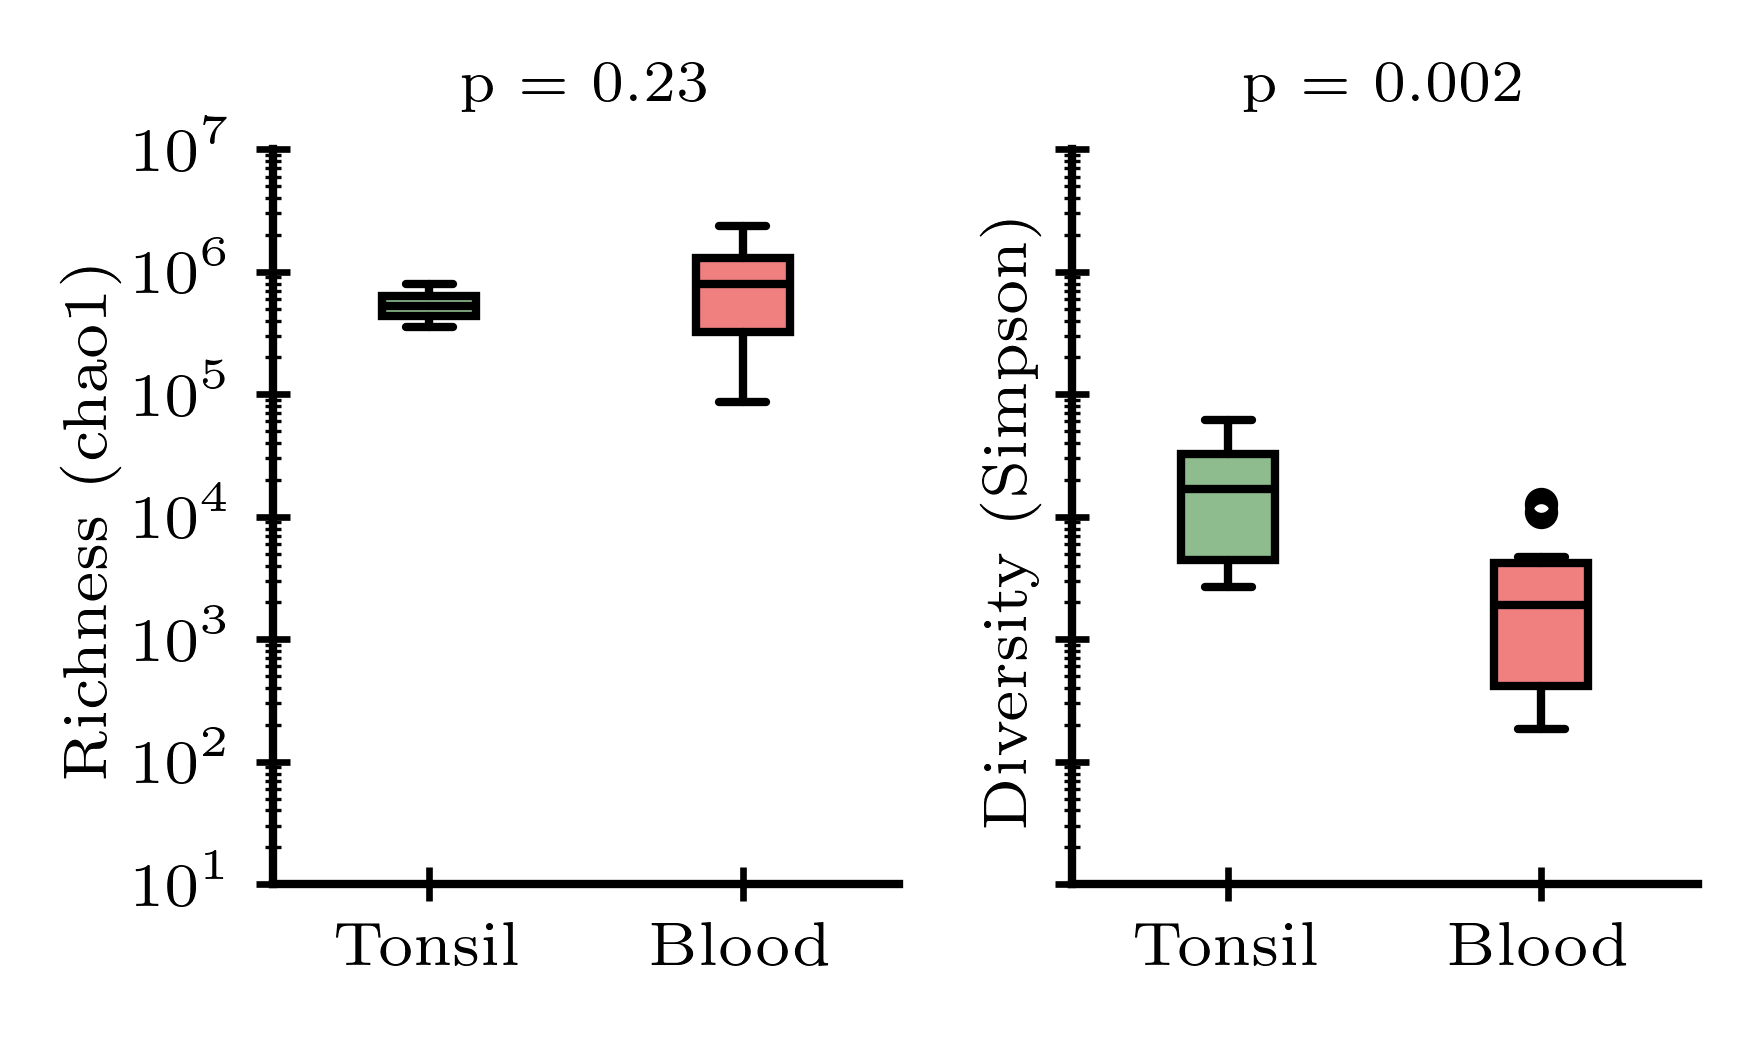

In [13]:
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[df_metrics['loc'] == 'tonsil'], df_metrics[df_metrics['loc'] == 'blood'], box_colors=["darkseagreen","lightcoral"],
                                                      x_labels=['Tonsil', 'Blood'], test='WCR')
plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity_blood_vs_tonsil.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Tonsil vs global

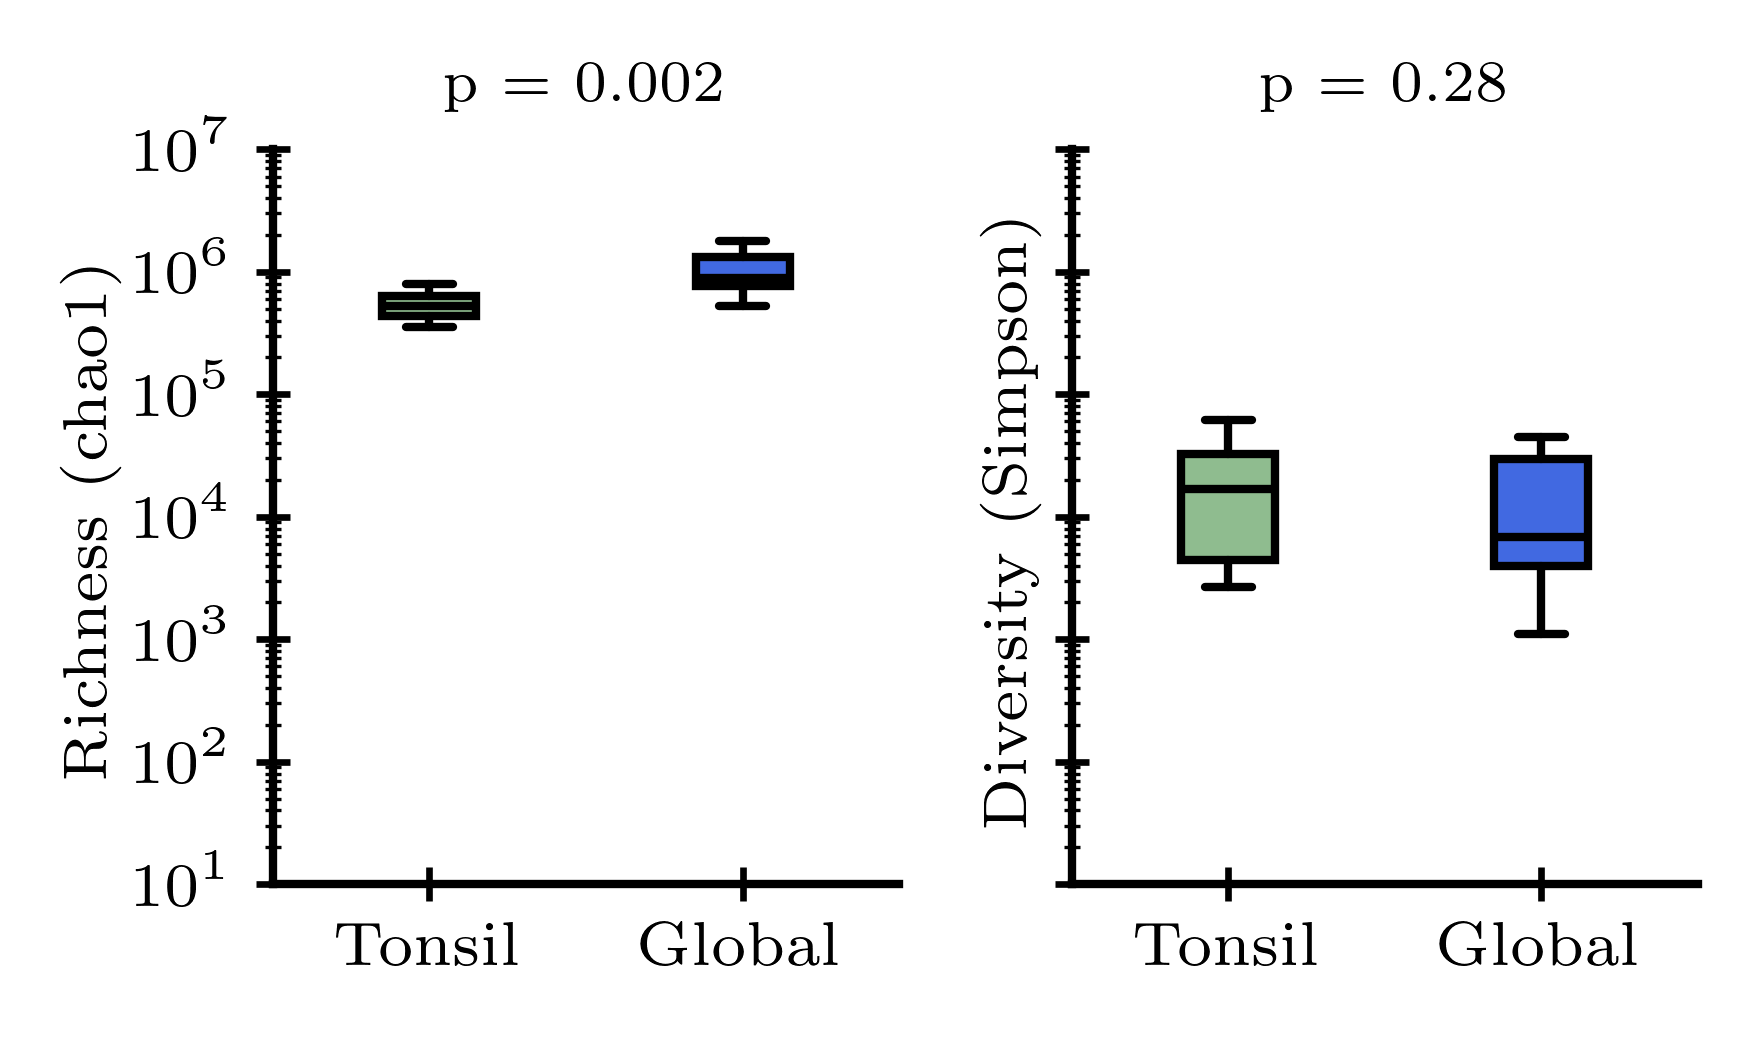

In [10]:
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[df_metrics['loc'] == 'tonsil'], df_metrics[df_metrics['loc'] == 'global'], box_colors=["darkseagreen","royalblue"],
                                                      x_labels=['Tonsil', 'Global'], test='WCR');

### Blood vs global

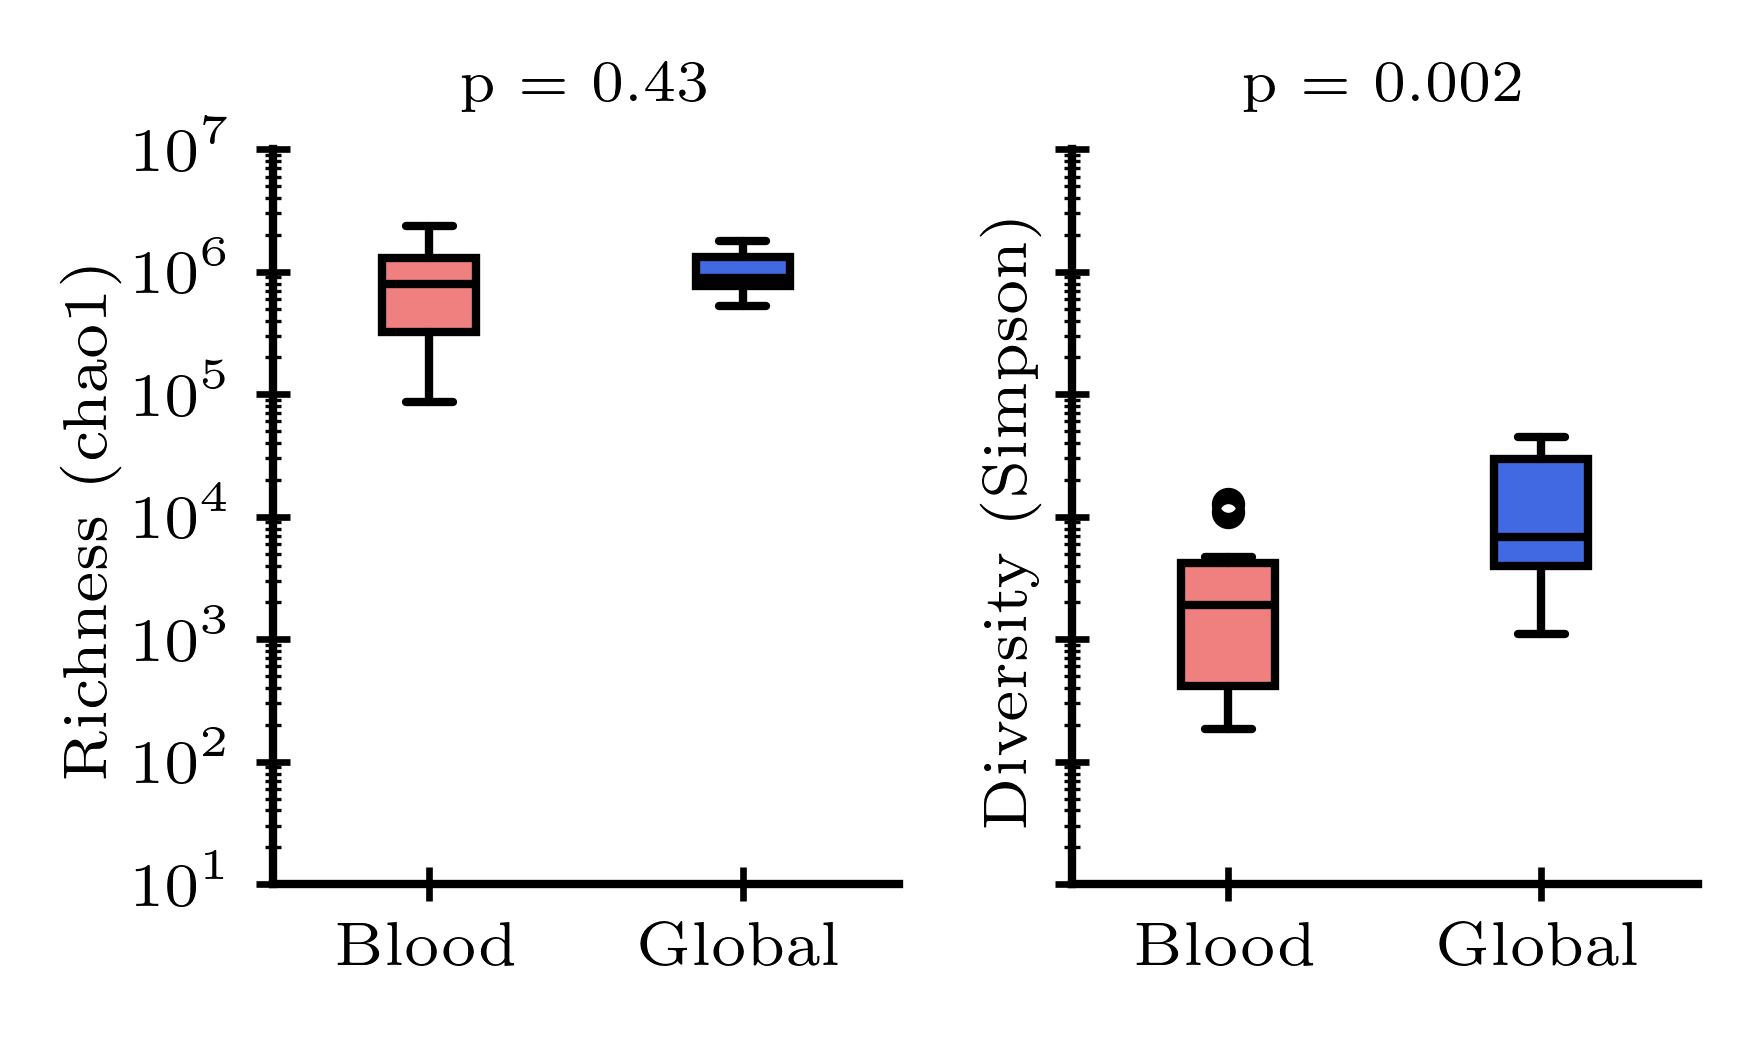

In [15]:
fig, ax = lib.plot_richness_and_diversity_differences(df_metrics[df_metrics['loc'] == 'blood'], df_metrics[df_metrics['loc'] == 'global'], box_colors=["lightcoral","royalblue"],
                                                      x_labels=['Blood', 'Global'], test='WCR');